In [13]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

   label                                               text
0    ham  Go until jurong point, crazy.. Available only ...
1    ham                      Ok lar... Joking wif u oni...
2   spam  Free entry in 2 a wkly comp to win FA Cup fina...
3    ham  U dun say so early hor... U c already then say...
4    ham  Nah I don't think he goes to usf, he lives aro...
5   spam  FreeMsg Hey there darling it's been 3 week's n...
6    ham  Even my brother is not like to speak with me. ...
7    ham  As per your request 'Melle Melle (Oru Minnamin...
8   spam  WINNER!! As a valued network customer you have...
9   spam  Had your mobile 11 months or more? U R entitle...
10   ham  I'm gonna be home soon and i don't want to tal...
11  spam  SIX chances to win CASH! From 100 to 20,000 po...
12  spam  URGENT! You have won a 1 week FREE membership ...
13   ham  I've been searching for the right words to tha...
14   ham                I HAVE A DATE ON SUNDAY WITH WILL!!
15  spam  XXXMobileMovieClub: To use you

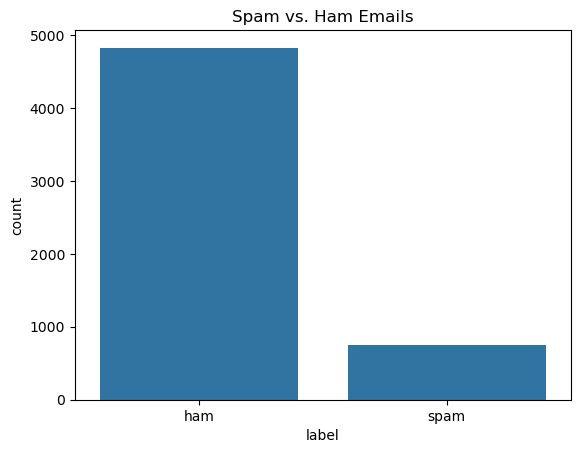

In [40]:
# Load the dataset
data = pd.read_csv('spam.csv', encoding='latin-1')  # Some datasets have encoding issues
data = data[['v1', 'v2']]  # Keep only 'label' and 'text' columns
data.columns = ['label', 'text']  # Rename columns

# Display first 5 rows
print(data.head(20))

# Check class distribution
print("\nClass Distribution:")
print(data['label'].value_counts())

# Visualize spam vs. ham (non-spam)
sns.countplot(x='label', data=data)
plt.title("Spam vs. Ham Emails")
plt.show()

In [41]:
# Convert labels to binary (0=ham, 1=spam)
data['label'] = data['label'].map({'ham': 0, 'spam': 1})

# Split into features (X) and target (y)
X = data['text']
y = data['label']

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
# Initialize TF-IDF Vectorizer (removes stop words)
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

# Fit and transform training data
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test data
X_test_tfidf = tfidf.transform(X_test)

print(f"Shape of TF-IDF matrix (Train): {X_train_tfidf.shape}")
print(f"Shape of TF-IDF matrix (Test): {X_test_tfidf.shape}")

Shape of TF-IDF matrix (Train): (4457, 5000)
Shape of TF-IDF matrix (Test): (1115, 5000)


In [30]:
# Initialize and train the model
model = LogisticRegression(max_iter=1000)  # Increase max_iter for convergence
model.fit(X_train_tfidf, y_train)

# Predict on test set
y_pred = model.predict(X_test_tfidf)

Accuracy: 0.9578


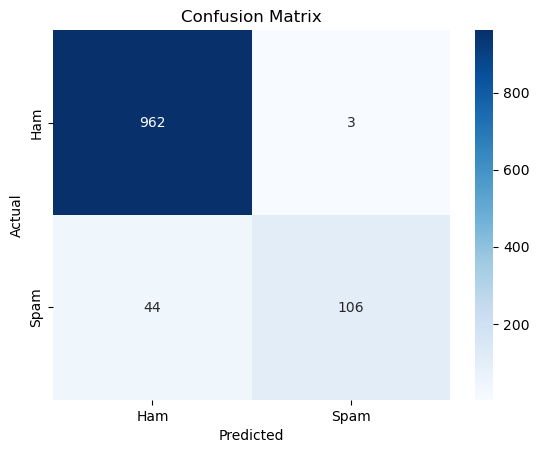


Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       0.97      0.71      0.82       150

    accuracy                           0.96      1115
   macro avg       0.96      0.85      0.90      1115
weighted avg       0.96      0.96      0.95      1115



In [31]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [32]:
def predict_spam(email_text):
    email_tfidf = tfidf.transform([email_text])
    prediction = model.predict(email_tfidf)
    return "Spam" if prediction[0] == 1 else "Ham"

# Test examples
print(predict_spam("You got a iPhone"))  # Spam
print(predict_spam("Hey, let's meet for lunch tomorrow."))  # Ham

Ham
Ham
